# Newtonverfahren

Das aus der AN1 bekannte Newtonverfahren zur Bestimmung einer Nullstelle einer differenzierbaren Funktion $f$ beruht auf der Approximation einer Funktion $f$ durch ihre Tangente, aka ihr **Taylorpolynom erster Ordnung**. Diese Approximation funktioniert bekanntlich auch für Funktionen
$$
    f: \mathbb{R}^n \to \mathbb{R}^n, \qquad f(x) \approx T_1(x, x_0) = f(x_0) + Df(x_0) \cdot (x - x_0)
$$

wobei $Df$ die **Jacobimatrix** von $f$ bezeichnet. Das entsprechend umformulierte Newtonverfahren lautet damit

* Wähle einen Startwert $x_0$
* Für $k = 0, 1, \ldots$
    * Löse das LGS  $Df(x_k) \cdot \delta = - f(x_k)$
    * Setze $x_{k+1} = x_k + \delta$

Es gibt im allgemeinen keinerlei Garantien, dass diese Iteration konvergiert. Das steht und fällt (unter anderem) mit dem Startwert $x_0$.

## Anwendungsbeispiel Roboterkinematik
Gegeben ein einfacher Roboter mit zwei Drehgelenken ("Schultergelenk, Ellenbogen") mit einstellbaren Gelenkwinkeln $\theta_1, \theta_2$. Die Armlängen $\ell_1 \geq \ell_2$ sind fest. Damit lassen sich Positionen $(x, y)$ innerhalb der Radien $\ell_1 - \ell_2 \leq r \leq \ell_1 + \ell_2$ anfahren.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import IFrame
from ipywidgets import interactive, widgets

IFrame("./NUM1_Praktikum_W7_RoboterMG.pdf", width=600, height=500)


## Kinematik: vorwärts und rückwärts 

Zur Steuerung benötigt man die **Vorwärtskinematik**

$$
    g: (\theta_1, \theta_2) \mapsto (x, y)
$$

um die Position $(x, y)$ aus den Gelenkwinkeln zu berechnen, sowie deren Inverse, die **Rückwärtskinematik**

$$
    g^{-1}: (x, y) \mapsto (\theta_1, \theta_2)
$$

zur Berechnung der Gelenkwinkel in Abhängigkeit einer (Soll-)Position $(x, y)$.

### Die Vorwärtskinematik
Die Vorwärtskinematik ist in unserem Beispiel nicht so schwierig:

$$
    \begin{pmatrix} x \\ y \end{pmatrix} = \begin{pmatrix}
        \ell_1 \cdot \cos(\theta_1) + \ell2 \cdot \cos(\theta_1 + \theta_2) \\
        \ell_1 \cdot \sin(\theta_1) + \ell2 \cdot \sin(\theta_1 + \theta_2) 
    \end{pmatrix}
$$


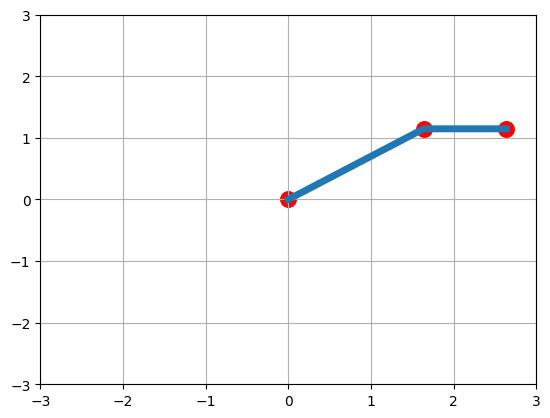

In [8]:
l1, l2 = 2, 1 
th1, th2 = 35 * np.pi/180, -35 * np.pi/180

# Vorwärtskinematik, P ist die Position des Ellbogens und T die Greiferposition
def forwardKin(th1, th2):
    P = l1 * np.array([np.cos(th1), np.sin(th1)])
    T = P + l2 * np.array([np.cos(th1 + th2), np.sin(th1 + th2)])
    return P, T

# Hilfsfunktion zum Plotten der Positionen
def plotPos(th1, th2):
    P, T = forwardKin(th1, th2)
    plt.plot([0, P[0], T[0]], [0, P[1], T[1]], linewidth = 5);
    plt.scatter([0, P[0], T[0]], [0, P[1], T[1]], s = 125, color = "r");
    plt.axis([-l1-l2,l1+l2, -l1-l2,l1+l2])
    plt.grid()

plotPos(th1, th2)


In [9]:
# interaktive Version davon, mit einstellbaren Winkeln theta1, theta2 
interactive_plot = interactive(plotPos, 
    th1 = widgets.FloatSlider(min=-np.pi, max=np.pi, step=0.1, value=1), 
    th2 = widgets.FloatSlider(min=-np.pi, max=np.pi, step=0.1, value=1) )
output = interactive_plot.children[-1]


output.figsize = (10, 10)
interactive_plot

interactive(children=(FloatSlider(value=1.0, description='th1', max=3.141592653589793, min=-3.141592653589793)…

### Rückwärtskinematik 
Die Rückwärtskinematik ist etwas schwieriger, und bei komplizierteren Mechanismen überhaupt nicht mehr geschlossen lösbar. Wir verwenden das Newtonverfahren, indem wir die Aufgabe als nichtlineares Gleichungssystem

\begin{eqnarray}
    \ell_1 \cdot \cos(\theta_1) + \ell2 \cdot \cos(\theta_1 + \theta_2) - x &\stackrel!=& 0 \\
    \ell_1 \cdot \sin(\theta_1) + \ell2 \cdot \sin(\theta_1 + \theta_2) - y &\stackrel!=& 0
\end{eqnarray}

für die beiden Gelenkwinkel $\theta_1, \theta_2$ auffassen (für gegebene $(x, y)$). Dazu brauchen wir noch die Jacobimatrix der Vorwärtskinematik:

$$
    Dg(\theta_1, \theta_2) = \ldots
$$

Die rasche Konvergenz (bei passenden Startwerten...) des Newtonverfahrens ist ein grosser Vorteil, wenn die Gleichungen für eine Robotersteuerung in Echtzeit gelöst werden müssen.

Eine einfache Umsetzung ist unten angegeben. Für eine praxistaugliche Umsetzung gäbe es natürlich noch diverse Punkte zu berücksichtigen...

In [ ]:
# Rückwärtskinematik
def backwardKin(x, y, tol = 1e-6):
    
    assert(l1 >= l2) # stillschweigende Annahme...
    
    # teste auf Arbeitsbereich
    r = np.hypot(x, y)
    if (l1 - l2 > r) or (r > l1 + l2):
        return th

    PRueck = l1 * np.array([np.cos(th1), np.sin(th1)])
    TRueck = PRueck + l2 * np.array([np.cos(th1 + th2), np.sin(th1 + th2)])

    # Funktion, deren Nullstelle gesucht ist: Abweichung von der Sollposition
    f = lambda th1, th2: np.array([
        # x fehler:
        l1 * np.cos(th1) + l2 * np.cos(th1 + th2) - x,
        # y fehler:
        l1 * np.sin(th1) + l2 * np.sin(th1 + th2) - y
    ])

    # ... und deren Jacobimatrix
    
    J = lambda th1, th2: np.array([
        #1 erste zeile der jaccobi matrix
        [-l1 * np.sin(th1) - l2 * np.sin(th1 + th2), -l2 * np.sin(th1 + th2)],
        ## 2. zeile der jaccobi matrix
        [ l1 * np.cos(th1) + l2 * np.cos(th1 + th2),  l2 * np.cos(th1 + th2)]
    ])

    # Newtoniteration
    <<snipp>>
 
    return <<snipp>>

# plot, ausgehend von (x, y) Werten
plotPosXY = lambda x, y: plotPos(*backwardKin(x, y))

# plot an einer Beispielposition
x, y = 0, 2
plotPosXY(x, y)
plt.grid()

SyntaxError: invalid syntax (3280526021.py, line 28)

In [ ]:
# interaktive Version davon, mit einstellbaren x, y - Werten 
r = l1+l2
interactive_plot = interactive(plotPosXY, 
    x = widgets.FloatSlider(min=-r, max=r, step=0.1, value=0), 
    y = widgets.FloatSlider(min=-r, max=r, step=0.1, value=2) )
output = interactive_plot.children[-1]
output.layout.height = '500px'
output.figsize = (10, 10)
interactive_plot